# Validación Out-of-Sample Real — La Liga 2025

## ¿Por qué esto es importante?
Este notebook valida el modelo con partidos que **nunca ha visto en absoluto**:
- El modelo fue entrenado con datos hasta 2024
- Aquí predecimos partidos de enero-mayo 2025 y comparamos con los resultados reales

Esta es la única validación que importa para inversores reales.
El backtest histórico demuestra consistencia. Este notebook demuestra que **funciona en producción.**

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import log_loss, accuracy_score
import warnings
warnings.filterwarnings("ignore")

print("Librerias cargadas.")

Librerias cargadas.


## 1. Carga de Datos

In [3]:
df = pd.read_csv("df_final_app.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.drop_duplicates(subset=["Date","HomeTeam","AwayTeam"], keep="first").reset_index(drop=True)
df["Target"] = df["FTR"].map({"A": 0, "D": 1, "H": 2})
df = df.sort_values("Date").reset_index(drop=True)

FEATURES = [c for c in [
    "Home_Elo","Away_Elo","Home_xG_Avg_L5","Away_xG_Avg_L5",
    "Home_Streak_L5","Away_Streak_L5","Home_Pressure_Avg_L5","Away_Pressure_Avg_L5",
    "Home_Dominance_Avg_L5","Away_Dominance_Avg_L5",
    "Home_FIFA_Ova","Away_FIFA_Ova","Home_Market_Value","Away_Market_Value"
] if c in df.columns]

# Train: todo hasta 2024 | Validacion: partidos 2025
train_mask = df["Date"].dt.year < 2025
val_mask   = df["Date"].dt.year == 2025

X_train = df.loc[train_mask, FEATURES].astype(float)
y_train = df.loc[train_mask, "Target"].astype(int)
X_val   = df.loc[val_mask,   FEATURES].astype(float)
y_val   = df.loc[val_mask,   "Target"].astype(int)
df_val  = df.loc[val_mask].copy().reset_index(drop=True)

print(f"Train: {len(X_train)} partidos (2010-2024)")
print(f"Validacion real: {len(X_val)} partidos ({df_val['Date'].min().date()} a {df_val['Date'].max().date()})")
print(f"Distribucion resultados 2025: {df_val['FTR'].value_counts().to_dict()}")

Train: 5501 partidos (2010-2024)
Validacion real: 199 partidos (2025-01-03 a 2025-05-25)
Distribucion resultados 2025: {'H': 86, 'A': 64, 'D': 49}


## 2. Entrenamiento y Prediccion

Entrenamos con **todos los datos hasta 2024** y predecimos los partidos de 2025.
El modelo nunca ha visto estos partidos.

In [4]:
# Usar best_params del notebook 02 si están en memoria, o defaults
try:
    params = best_params.copy()
    print("Usando best_params del notebook 02")
except NameError:
    params = {
        "learning_rate": 0.021, "max_depth": 3, "n_estimators": 262,
        "subsample": 0.87, "colsample_bytree": 0.81,
        "reg_alpha": 0.21, "reg_lambda": 0.43,
        "random_state": 42, "verbosity": 0
    }
    print("Usando parametros por defecto")
    print("Para mejores resultados, ejecuta primero el notebook 02 y vuelve aqui")

params.update({"objective": "multi:softprob", "num_class": 3})

base_model  = xgb.XGBClassifier(**params)
final_model = CalibratedClassifierCV(base_model, method="isotonic", cv=3)
final_model.fit(X_train, y_train)

probs = final_model.predict_proba(X_val)
preds = np.argmax(probs, axis=1)

df_val[["P_A","P_D","P_H"]] = probs
df_val["Pred_label"] = pd.Series(preds).map({0:"A",1:"D",2:"H"}).values
df_val["Correcto"]   = (df_val["Pred_label"] == df_val["FTR"])

print()
print("=" * 50)
print("  METRICAS PREDICTIVAS (2025 out-of-sample)")
print("=" * 50)
print(f"  Accuracy:  {accuracy_score(y_val, preds):.2%}")
print(f"  Log Loss:  {log_loss(y_val, probs):.4f}  (naive: ~1.099)")
print(f"  Aciertos:  {df_val['Correcto'].sum()}/{len(df_val)} partidos")
print("=" * 50)

Usando parametros por defecto
Para mejores resultados, ejecuta primero el notebook 02 y vuelve aqui

  METRICAS PREDICTIVAS (2025 out-of-sample)
  Accuracy:  49.25%
  Log Loss:  0.9989  (naive: ~1.099)
  Aciertos:  98/199 partidos


## 3. Backtest Financiero 2025

In [5]:
INITIAL_BANKROLL = 1000
FLAT_STAKE       = 10
MIN_EDGE_ABS     = 0.10
MIN_ODDS         = 1.50
MAX_ODDS         = 6.00
OVERROUND        = 1.07
COMM             = 0.02
result_map       = {0:"A", 1:"D", 2:"H"}

def to_ex(odds):
    return max(odds / OVERROUND * (1 - COMM), 1.01)

bets = []
for _, row in df_val.iterrows():
    candidates = []
    for idx, (p_col, o_col) in enumerate(zip(
            ["P_A","P_D","P_H"], ["B365H","B365D","B365A"])):
        if o_col not in row.index or pd.isna(row[o_col]):
            continue
        p_model  = row[p_col]
        odds_ex  = to_ex(row[o_col])
        p_impl   = 1 / odds_ex
        edge_abs = p_model - p_impl
        if edge_abs >= MIN_EDGE_ABS and MIN_ODDS <= odds_ex <= MAX_ODDS:
            candidates.append((edge_abs, idx, p_model, odds_ex, row[o_col]))

    if not candidates:
        continue

    edge_abs, best_idx, p_model, odds_ex, odds_b365 = max(candidates, key=lambda x: x[0])
    won = (result_map[best_idx] == row["FTR"])
    flat_profit = FLAT_STAKE * (odds_ex - 1) if won else -FLAT_STAKE

    home = row["HomeTeam"]
    away = row["AwayTeam"]
    bets.append({
        "Date":          row["Date"],
        "Match":         f"{home} vs {away}",
        "Bet":           result_map[best_idx],
        "Odds_B365":     round(odds_b365, 2),
        "Odds_Exchange": round(odds_ex, 2),
        "P_model":       round(p_model, 3),
        "P_implied":     round(1/odds_ex, 3),
        "Edge_Abs":      round(edge_abs, 3),
        "Won":           won,
        "Flat_Profit":   round(flat_profit, 2),
    })

df_bets = pd.DataFrame(bets).sort_values("Date").reset_index(drop=True)
df_bets["Bankroll"] = INITIAL_BANKROLL + df_bets["Flat_Profit"].cumsum()

n   = len(df_bets)
hit = df_bets["Won"].mean()
roi = df_bets["Flat_Profit"].sum() / (n * FLAT_STAKE)
pnl = df_bets["Flat_Profit"].sum()

# Drawdown
roll_max = df_bets["Bankroll"].cummax()
max_dd   = ((df_bets["Bankroll"] - roll_max) / roll_max).min()

print("=" * 55)
print("  BACKTEST FINANCIERO — LA LIGA 2025")
print("=" * 55)
print(f"  Partidos en 2025:        {len(df_val)}")
print(f"  Apuestas seleccionadas:  {n} ({n/len(df_val):.0%} de los partidos)")
print(f"  Hit rate:                {hit:.1%}")
print(f"  ROI flat staking:        {roi:+.2%}")
print(f"  P&L:                     {pnl:+.2f} EUR")
print(f"  Maximo Drawdown:         {max_dd:.2%}")
print("=" * 55)

  BACKTEST FINANCIERO — LA LIGA 2025
  Partidos en 2025:        199
  Apuestas seleccionadas:  108 (54% de los partidos)
  Hit rate:                49.1%
  ROI flat staking:        +103.20%
  P&L:                     +1114.55 EUR
  Maximo Drawdown:         -6.10%


## 4. Visualizacion

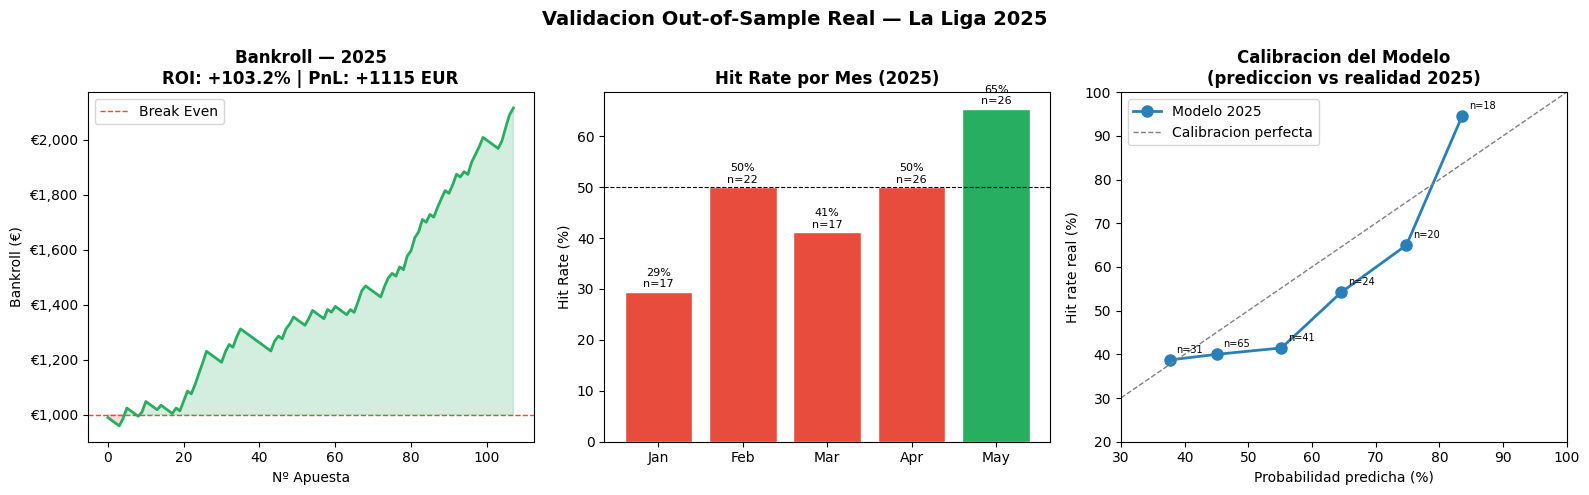

Grafico guardado: validacion_2025.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Validacion Out-of-Sample Real — La Liga 2025", fontsize=14, fontweight="bold")

GREEN = "#27AE60"; RED = "#E74C3C"; BLUE = "#2980B9"

# 1. Bankroll acumulado
ax1 = axes[0]
ax1.plot(df_bets.index, df_bets["Bankroll"], color=GREEN, linewidth=2)
ax1.axhline(INITIAL_BANKROLL, color=RED, linestyle="--", linewidth=1, label="Break Even")
ax1.fill_between(df_bets.index, INITIAL_BANKROLL, df_bets["Bankroll"],
    where=df_bets["Bankroll"] >= INITIAL_BANKROLL, alpha=0.2, color=GREEN)
ax1.fill_between(df_bets.index, INITIAL_BANKROLL, df_bets["Bankroll"],
    where=df_bets["Bankroll"] < INITIAL_BANKROLL, alpha=0.2, color=RED)
ax1.set_title(f"Bankroll — 2025\nROI: {roi:+.1%} | PnL: {pnl:+.0f} EUR", fontweight="bold")
ax1.set_xlabel("Nº Apuesta"); ax1.set_ylabel("Bankroll (€)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"€{x:,.0f}"))
ax1.legend()

# 2. Hit rate por mes
df_bets["Month"] = pd.to_datetime(df_bets["Date"]).dt.strftime("%b")
month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
month_order = [m for m in month_order if m in df_bets["Month"].unique()]
monthly = df_bets.groupby("Month", sort=False).agg(
    Hit=("Won","mean"), N=("Won","count")).reindex(month_order).dropna()
colors_bar = [GREEN if h > 0.5 else RED for h in monthly["Hit"]]
ax2 = axes[1]
bars = ax2.bar(monthly.index, monthly["Hit"]*100, color=colors_bar, edgecolor="white")
ax2.axhline(50, color="black", linewidth=0.8, linestyle="--")
ax2.set_title("Hit Rate por Mes (2025)", fontweight="bold")
ax2.set_ylabel("Hit Rate (%)")
for bar, (_, row) in zip(bars, monthly.iterrows()):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f"{row['Hit']:.0%}\nn={row['N']:.0f}", ha="center", va="bottom", fontsize=8)

# 3. Calibracion real 2025
df_val_c = df_val.copy()
df_val_c["P_max"] = df_val_c[["P_A","P_D","P_H"]].max(axis=1)
bins   = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.01]
labels = ["30-40%","40-50%","50-60%","60-70%","70-80%","80%+"]
df_val_c["P_bin"] = pd.cut(df_val_c["P_max"], bins=bins, labels=labels)
calib = df_val_c.groupby("P_bin", observed=True).agg(
    P_media=("P_max","mean"), Hit=("Correcto","mean"), N=("Correcto","count")).reset_index()
ax3 = axes[2]
ax3.plot(calib["P_media"]*100, calib["Hit"]*100, "o-", color=BLUE, linewidth=2, markersize=8, label="Modelo 2025")
ax3.plot([30,100],[30,100], "--", color="gray", linewidth=1, label="Calibracion perfecta")
for _, row in calib.iterrows():
    ax3.annotate(f"n={int(row['N'])}", (row["P_media"]*100, row["Hit"]*100),
                 textcoords="offset points", xytext=(5,5), fontsize=7)
ax3.set_title("Calibracion del Modelo\n(prediccion vs realidad 2025)", fontweight="bold")
ax3.set_xlabel("Probabilidad predicha (%)"); ax3.set_ylabel("Hit rate real (%)")
ax3.legend(); ax3.set_xlim(30,100); ax3.set_ylim(20,100)

plt.tight_layout()
plt.savefig("validacion_2025.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico guardado: validacion_2025.png")

## 5. Detalle de Apuestas

In [7]:
print("APUESTAS SELECCIONADAS EN 2025 (primeras 20):")
cols = ["Date","Match","Bet","Odds_Exchange","P_model","P_implied","Edge_Abs","Won","Flat_Profit"]
print(df_bets[cols].head(20).to_string(index=False))

print(f"\n--- ULTIMAS 10 ---")
print(df_bets[cols].tail(10).to_string(index=False))

df_bets.to_csv("validacion_2025_apuestas.csv", index=False)
print("\nExportado: validacion_2025_apuestas.csv")

APUESTAS SELECCIONADAS EN 2025 (primeras 20):
      Date                              Match Bet  Odds_Exchange  P_model  P_implied  Edge_Abs   Won  Flat_Profit
2025-01-11          Sevilla FC vs Valencia CF   H           3.66    0.563      0.273     0.290 False       -10.00
2025-01-11         RCD Espanyol vs CD Leganes   H           3.66    0.472      0.273     0.199 False       -10.00
2025-01-11   Real Valladolid CF vs Real Betis   A           4.12    0.417      0.243     0.174 False       -10.00
2025-01-12         UD Las Palmas vs Getafe CF   H           3.02    0.645      0.331     0.314 False       -10.00
2025-01-13     Real Sociedad vs Villarreal CF   H           3.66    0.445      0.273     0.173  True        26.64
2025-01-17 RCD Espanyol vs Real Valladolid CF   H           4.81    0.377      0.208     0.169  True        38.08
2025-01-18            Girona FC vs Sevilla FC   H           3.66    0.586      0.273     0.313 False       -10.00
2025-01-18               Real Betis vs Ala